made by Kataoka @2024/06/10.

Vertification for Random Fourier Feature.  
.

reference : https://arxiv.org/abs/2006.10739

Environment built by Docker, Pytorch Image "23.08-py3".
https://catalog.ngc.nvidia.com/orgs/nvidia/containers/pytorch


In [1]:
# Standard Library

import os
import sys
import copy
import glob
import time
import pickle
import matplotlib.cm
import matplotlib.pyplot as plt

# External Library
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

# Settings

In [2]:
# Set default dtype to float32
torch.set_default_dtype(torch.float)

# PyTorch random number generator
torch.manual_seed(1234)

# Random number generators in other libraries
np.random.seed(1234)

# Device configuration
# device = torch.device("cpu")
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Function

In [3]:
### Multilayer perceptron

class DNN(nn.Module):
    
    """
    This is Simple Multilayer perceptron class.
    """

    def __init__(self, input_dim, output_dim, num_layer, num_neuron):
        
        super(DNN, self).__init__()
        
        # instance variables
        self.input_size = input_dim
        self.output_size = output_dim
        self.num_layer = num_layer
        self.num_neuron = num_neuron

        # layers
        self.inputs = nn.Linear(input_dim, num_neuron)
        for i in range(1, self.num_layer):
            exec_command = "self.fc" + str(i) + " = nn.Linear(num_neuron, num_neuron)"
            exec(exec_command)
        self.outputs = nn.Linear(num_neuron, output_dim)
        
        # activation function
        self.activation = nn.ReLU()
        
        # weight initialization
        """nn.init.kaiming_normal_(self.inputs.weight.data)
        nn.init.zeros_(self.inputs.bias.data)
        nn.init.kaiming_normal_(self.outputs.weight.data)
        nn.init.zeros_(self.outputs.bias.data)

        for i in range(1, self.num_layer):
            exec_command_1 = "nn.init.kaiming_normal_(self.fc" + str(i) + ".weight.data)"
            exec(exec_command_1)
            exec_command_2 = "nn.init.zeros_(self.fc" + str(i) + ".bias.data)"
            exec(exec_command_2)"""

        
    def forward(self, x):
            
        x = self.activation(self.inputs(x))
        for i in range(1, self.num_layer):
            exec_command = "x = self.activation(self.fc" + str(i) + "(x))"
            exec(exec_command)
        x = self.outputs(x)
        
        return x

In [4]:
class RMSELoss(nn.Module):
    def __init__(self):
        super(RMSELoss, self).__init__()

    def forward(self, pred, target):
        return torch.sqrt(torch.mean((pred - target) ** 2))

In [5]:
def pink_noise(n, alpha):
    
    """
    Return pink noise.
    """
    
    gaussian_vector = np.random.randn(n)
    scaled_vector = gaussian_vector / (np.arange(1, n + 1) ** alpha)

    return np.real(np.fft.ifft(scaled_vector))

In [6]:
def fourier_feature_mapping(x, p, n):
    
    """
    Generate Fourier Feature.
    """
    
    gamma = np.empty(shape=(x.shape[0], 0))
    
    for i in range(1, n+1):
        
        a_i = 1/i**p
        b_i = i
        ff = np.concatenate([a_i*np.cos(2*np.pi*b_i*x), a_i*np.sin(2*np.pi*b_i*x)], axis=1)
        
        gamma = np.concatenate([gamma, ff], axis=1)
        
    return gamma

In [7]:
def plot_signal(x, signal, predict=None, c=8):
    
    """
    plot signal
    """
    
    fig = plt.figure(figsize = (7.5, 4))
    ax = fig.add_subplot(111)
    
    ax.plot(x, signal, label="Original Signal")
    if type(predict)==np.ndarray or type(predict)==torch.tensor:
        ax.plot(x, predict, label="Predict Signal")
    ax.scatter(x[0::c], signal[0::c], c="k", label="Trainig Data")
    
    ax.set_xlabel("x", size = 12)
    ax.set_ylabel("signal", size = 12)
    
    ax.set_xlim([min(x), max(x)])
    ax.legend(loc="best")
    
    return fig

In [8]:
def plot_loss(train_loss, test_loss, every_epoch):
    
    """
    plot loss
    """
    
    fig = plt.figure(figsize = (7.5, 4))
    ax = fig.add_subplot(111)
    
    x = every_epoch * np.arange(1, len(train_loss)+1)
    
    ax.plot(x, train_loss, label="Train Loss")
    ax.plot(x, test_loss, label="Test Loss")
    
    ax.set_xlabel("epoch", size = 12)
    ax.set_ylabel("loss", size = 12)
    
    ax.set_yscale("log")
    ax.set_xlim([min(x), max(x)])
    ax.legend(loc="best")
    
    return fig

# Main

In [9]:
### parameter

c = 8
n = 32
alpha = 1.0

model_map = {}
loss_map = {}

In [10]:
### generate signal

x = np.linspace(0, 1.0, c*n).reshape(-1, 1)
signal = pink_noise(c*n, alpha).reshape(-1, 1)

In [11]:
### generate fourier feature

fourier_feature_mapping(x, 1, len(x)//2).shape

(256, 256)

# No Mapping

In [12]:
### split data

train_x = torch.tensor(x[0::c]).float().to(device)
train_signal = torch.tensor(signal[0::c]).float().to(device)

test_x = torch.tensor(x[~np.isin(x, x[0::c])].reshape(-1,1)).float().to(device)
test_signal = torch.tensor(signal[~np.isin(signal, signal[0::c])].reshape(-1,1)).float().to(device)

In [13]:
train_x.shape, train_signal.shape, test_x.shape, test_signal.shape

(torch.Size([32, 1]),
 torch.Size([32, 1]),
 torch.Size([224, 1]),
 torch.Size([224, 1]))

In [14]:
### build a model

model = DNN(1, 1, 4, 1024).to(device)

In [15]:
### training config

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = RMSELoss()
nIter = 10000

In [16]:
### training

train_history = []
test_history = []
model.train()
        
for epoch in range(1,nIter):

    optimizer.zero_grad()
    
    outputs = model(train_x)
    loss = criterion(outputs, train_signal)
    
    loss.backward()
    optimizer.step()

    train_loss = criterion(model(train_x), train_signal)
    test_loss = criterion(model(test_x), test_signal)

    if epoch%1000==0:

        print(
            "Epoch: %d,  trainLoss : %.8f,  testLoss : %.8f" % 
            (
                epoch,
                train_loss.item(),
                test_loss.item()
            )
        )
        
    if epoch%1==0:
        train_history.append(train_loss.item())
        test_history.append(test_loss.item())

Epoch: 1000,  trainLoss : 0.01407366,  testLoss : 0.01371411
Epoch: 2000,  trainLoss : 0.00361449,  testLoss : 0.00333240
Epoch: 3000,  trainLoss : 0.00291401,  testLoss : 0.00307813
Epoch: 4000,  trainLoss : 0.00149073,  testLoss : 0.00135014
Epoch: 5000,  trainLoss : 0.00215497,  testLoss : 0.00195427
Epoch: 6000,  trainLoss : 0.00104804,  testLoss : 0.00118883
Epoch: 7000,  trainLoss : 0.00110811,  testLoss : 0.00107523
Epoch: 8000,  trainLoss : 0.00109412,  testLoss : 0.00105839
Epoch: 9000,  trainLoss : 0.00107072,  testLoss : 0.00103808


In [17]:
### result loss

model.eval()
prediction = model(torch.tensor(x).float().to(device)).detach().cpu().numpy()

print("Train Loss: {}".format(criterion(model(train_x), train_signal).item()))
print("Test Loss: {}".format(criterion(model(test_x), test_signal).item()))

Train Loss: 0.0011109118349850178
Test Loss: 0.0012766049476340413


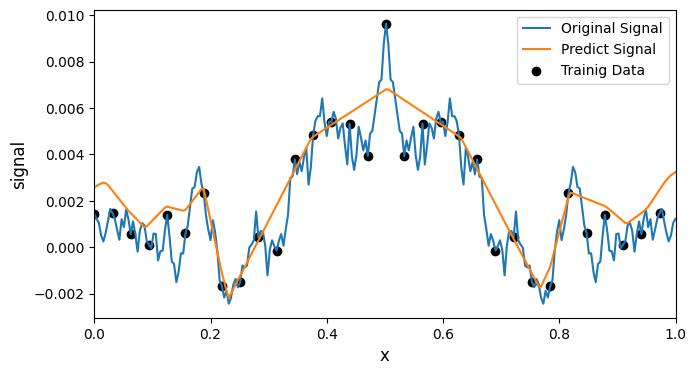

In [18]:
### prediction

fig = plot_signal(x=x, signal=signal, predict=prediction, c=8)

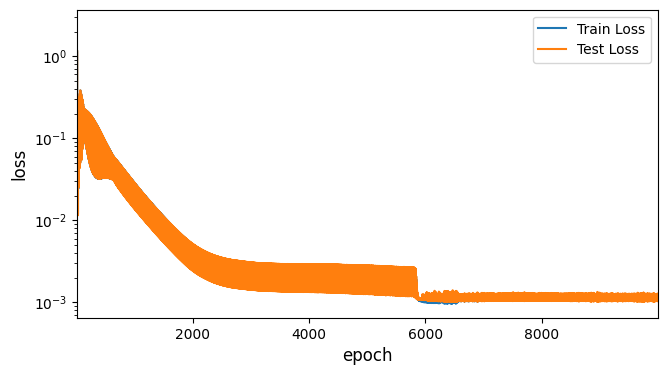

In [19]:
### loss curve

fig = plot_loss(train_history, test_history, 1)

In [20]:
### add map

model_map["no_mapping"] = model
loss_map["no_mapping"] = [train_history, test_history]

# Mapping(p=1)

In [21]:
### split data

ff = fourier_feature_mapping(x, 1, len(x)//2)

train_x = torch.tensor(ff[0::c]).float().to(device)
train_signal = torch.tensor(signal[0::c]).float().to(device)

test_x = torch.tensor(ff[~(ff[:, None] == ff[0::c]).all(-1).any(-1)]).float().to(device)
test_signal = torch.tensor(signal[~np.isin(signal, signal[0::c])]).float().to(device)

In [22]:
train_x.shape, train_signal.shape, test_x.shape, test_signal.shape

(torch.Size([32, 256]),
 torch.Size([32, 1]),
 torch.Size([224, 256]),
 torch.Size([224]))

In [23]:
### build a model

model = DNN(256, 1, 4, 1024).to(device)

In [24]:
### training config

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = RMSELoss()
nIter = 10000

In [25]:
### training

train_history = []
test_history = []
model.train()
        
for epoch in range(1,nIter):

    optimizer.zero_grad()
    
    outputs = model(train_x)
    loss = criterion(outputs, train_signal)
    
    loss.backward()
    optimizer.step()

    train_loss = criterion(model(train_x), train_signal)
    test_loss = criterion(model(test_x), test_signal)

    if epoch%1000==0:

        print(
            "Epoch: %d,  trainLoss : %.8f,  testLoss : %.8f" % 
            (
                epoch,
                train_loss.item(),
                test_loss.item()
            )
        )
        
    if epoch%1==0:
        train_history.append(train_loss.item())
        test_history.append(test_loss.item())

Epoch: 1000,  trainLoss : 0.00071317,  testLoss : 0.00306170
Epoch: 2000,  trainLoss : 0.00052846,  testLoss : 0.00304187
Epoch: 3000,  trainLoss : 0.00049937,  testLoss : 0.00303656
Epoch: 4000,  trainLoss : 0.00053941,  testLoss : 0.00303795
Epoch: 5000,  trainLoss : 0.00055327,  testLoss : 0.00300072
Epoch: 6000,  trainLoss : 0.00070777,  testLoss : 0.00302125
Epoch: 7000,  trainLoss : 0.00048608,  testLoss : 0.00295023
Epoch: 8000,  trainLoss : 0.00057082,  testLoss : 0.00295441
Epoch: 9000,  trainLoss : 0.00052941,  testLoss : 0.00295174


In [26]:
### result loss

model.eval()
prediction = model(torch.tensor(ff).float().to(device)).detach().cpu().numpy()

print("Train Loss: {}".format(criterion(model(train_x), train_signal).item()))
print("Test Loss: {}".format(criterion(model(test_x), test_signal).item()))

Train Loss: 0.0007490467978641391
Test Loss: 0.0031296382658183575


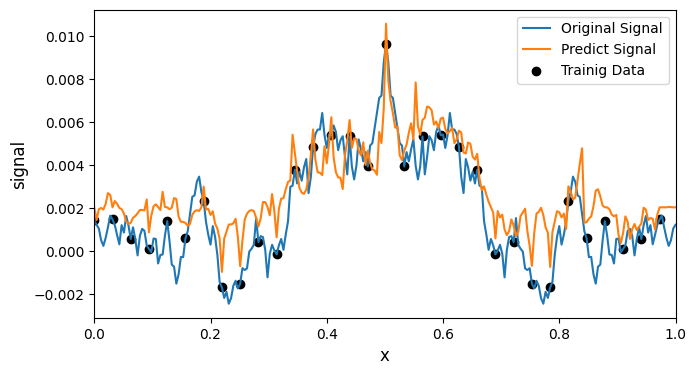

In [27]:
### prediction

fig = plot_signal(x=x, signal=signal, predict=prediction, c=8)

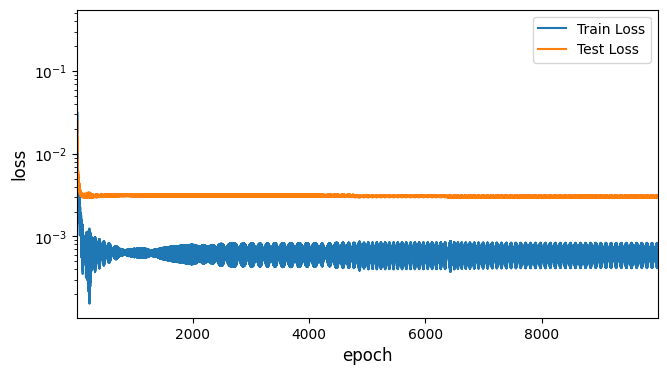

In [28]:
### loss curve

fig = plot_loss(train_history, test_history, 1)

In [29]:
### add map

model_map["no_mapping"] = model
loss_map["no_mapping"] = [train_history, test_history]